In [2]:
# 导入函数库
import os

os.chdir('/home/xizhang/MRCDFT/MR_CDFT_f90/dataprocessing')
from functionbox import *


In [3]:
class CoresManager:
    def __init__(self, A, element, datapath, file_path, save_path):
        self.element = element
        self.A = A
        # self.n0f = n0f
        # self.pnp = pnp
        # self.nbeta = nbeta
        self.path = datapath   # 代码结果
        self.file_path = file_path
        # self.cvn = f"{self.A}{self.element}_{self.n0f}_{self.pnp}_{self.nbeta}"
        self.save_path = save_path
        self.ID = f"{self.A}{self.element}"
        self.gcm_energy = None


        if not os.path.exists(self.save_path) and os.path.exists(self.file_path):
            os.makedirs(self.save_path)
        # <class 'pandas.DataFrame'>用个空表格

        self.df = pd.DataFrame()
        self.gcm_energy = None
    
    # def cvn_to_text(self):
    #     i,j,k,l = self.cvn.split("_")
    #     return f"{i} n0f: {j} pnp: {k} nbeta: {l}"
    
    
    def getdata(self, load_method):
        # print(type(self.df))
        self.df = load_method

        # print(type(self.df))

In [6]:

# 设置科研风格绘图参数
plt.rcParams.update({
    'font.size': 12,              # 字体大小
    'font.family': 'serif',       # 字体, 可选:sans-serif, sans-serif, monospace, serif-greek, serif-symbol
    'mathtext.fontset': 'cm',     # 数学字字体，
    'axes.linewidth': 1.5,        # 轴线宽度
    'lines.linewidth': 2,         # 线宽
    'xtick.major.width': 1.5,     # 轴线宽度
    'ytick.major.width': 1.5,     # 轴线宽度
    'xtick.major.size': 6,        # 轴线长度
    'ytick.major.size': 6,        # 轴线长度
    'figure.figsize': [8, 6],     # 图像大小
    'figure.dpi': 100,            # 图像分辨率，
    'savefig.dpi': 300,           # 图片分辨率，
    'savefig.format': 'jpg',      # 图片保存格式
    'savefig.bbox': 'tight'       # 保存图片时自动调整边界
})

elements = ["Ca"]
element = elements[0]
# The rule of naming: A + n0f + pnp + nbeta
A = 40
As = [40, 42, 44, 46, 48]
# As = [41]
# As = [42]

# pnps = [111]   # project of particle number or not
# nbetas = [20,12]
cores = {}
save_path = f"results/{A}{element}/pictures"
isbindingenergypositive = False
choose_files_dict = {"11":[], "10":[], "01":[]}

for element in elements:
    for A in As:
        timelist = []
        timelistA = []
        timelistP = []
        for filename in os.listdir(f"../datas/{A}{element}"):
            # print(filename)
            filetime = filename.split("_")[1]
            if len(filetime)>15:
                for x in ["10_", "01_", "11_"]:
                    # print(x in filename)
                    if "results" in os.listdir(f"../datas/{A}{element}/{filename}") or x in filename:
                        # print(filename)
                        if x in filename:
                            if x == "10_":
                                timelistA.append(f"{filename}")
                            elif x == "01_":
                                timelistP.append(f"{filename}")
                            elif x == "11_":
                                timelist.append(f"{filename}")
        # 排序
        # print(timelist)
        timelist.sort()
        # print(timelist)
        timelistA.sort()
        timelistP.sort()

        choose_files_dict["11"].append(timelist[-1])
        choose_files_dict["10"].append(timelistA[-1])
        choose_files_dict["01"].append(timelistP[-1])
# print(choose_files_dict)
coress = {}
energy_list = []
cores_dict = {}
new_choose_files_dict = {}
gcm_energy = {}
for key, choose_files in choose_files_dict.items():
    for element in elements:
        for A in As:
            if f"{A}{element}" in new_choose_files_dict.keys():  
                pass
            else:
                new_choose_files_dict[f"{A}{element}"] = []
            for filename in choose_files:
                if filename in os.listdir(f"../datas/{A}{element}"):
                    df = pd.read_csv(f"../datas/{A}{element}/{filename}/results/kern_data.csv")
                    datapath = f"../datas/{A}{element}/{filename}/results/"
                    file_path = f"../datas/{A}{element}/{filename}/output/CDFT_Expectation.out"
                    save_path = f"./results/{A}{element}/{filename}"
                    core = CoresManager(A, element, filename, file_path, save_path)
                    core.getdata(df)
                    core.df.drop(columns=['charge-Radius'], inplace=True)
                    
                    core.df = core.df.rename(columns={"energy_J0": f"energy_J0{key}"})
                    # print(core.df)
                    # print(core.df)
                    # print(core.ID)
                    cores[core.ID] = core
             
                    new_choose_files_dict[f"{A}{element}"].append(core.df)
                    
                    if key == "11":
                        with open(f'../datas/{A}{element}/{filename}/exec/energy.txt', 'r') as f:
                            num_str = f.read().strip()  # 去除首尾空格/换行
                            num = float(num_str)  # 先转为浮点数
                            # num_int = int(num_float)    # 再转为整数（直接截断小数部分）
                            print(num)  # 输出：-344
                            core.gcm_energy = num
                            gcm_energy[f"{A}{element}"] = core.gcm_energy
                            # print()
                    # print("载入",key, core.ID)
                    cores_dict[key] = cores
                        # core.gcm_energy = num
                # print(filename)

                # if filename.endswith(".csv"):
                #     if filename.startswith(f"{element}"):
                #         cores[filename] = Core(f"results/{A}{element}", element, A, isbindingenergypositive)
            # if f"{A}{element}" in os.listdir("results"):
            #     cores[f"{A}{element}"] = Core(f"results/{A}{element}", element, A, isbindingenergypositive)
            # for n0f in n0fs:
            #     for pnp in pnps:
            #         for nbeta in nbetas:
# temp_list = list(cores.keys()) # 获取键
# print(temp_list)
# df = cores[temp_list[0]].df
# print(df.head()) 
# print(new_choose_files_dict.keys())
core_dict = {}
for key, core_list in new_choose_files_dict.items():
    # print(key)
    core_list[1].drop(columns=['Etot'], inplace=True)
    core_list[2].drop(columns=['Etot'], inplace=True)
    merged_df = (
                    core_list[0].merge(core_list[1], on=['beta2', 'beta3'], how='outer')
                    .merge(core_list[2], on=['beta2', 'beta3'], how='outer')
                )
    datapath = f"../datas/key/filename/results/"
    file_path = f"../datas/key/filename/output/CDFT_Expectation.out"
    save_path = f"./results/key/filename"
    core = CoresManager(key[0:2], key[2:4], filename, file_path, save_path)
    core.getdata(merged_df)
    core.gcm_energy = gcm_energy[key]
    core_dict[core.ID] = core
    # print(core.ID)
print(core_dict)
print(core_dict["42Ca"].gcm_energy)
# print(core_list)

-344.5309
-373.2006
-386.4671
-401.1499
-416.614
{'40Ca': <__main__.CoresManager object at 0x2b86e9400fd0>, '42Ca': <__main__.CoresManager object at 0x2b86e9447450>, '44Ca': <__main__.CoresManager object at 0x2b86e9483d50>, '46Ca': <__main__.CoresManager object at 0x2b86e9489ed0>, '48Ca': <__main__.CoresManager object at 0x2b86e9483a50>}
-373.2006


In [40]:
print(cores_dict["11"]["48Ca"].df.head())
print(cores_dict["10"]["48Ca"].df.head())

   beta2  beta3  energy_J0        Etot  charge-Radius
0  -0.50   0.01 -399.59150 -397.000254       3.738860
1  -0.45   0.01 -402.52922 -400.942332       3.694170
2  -0.40   0.01 -404.79093 -404.742975       3.647253
3  -0.35   0.01 -407.14594 -407.100031       3.602235
4  -0.30   0.01 -408.54327 -408.126154       3.571766
   beta2  beta3  energy_J0        Etot  charge-Radius
0  -0.50   0.01 -399.59150 -397.000254       3.738860
1  -0.45   0.01 -402.52922 -400.942332       3.694170
2  -0.40   0.01 -404.79093 -404.742975       3.647253
3  -0.35   0.01 -407.14594 -407.100031       3.602235
4  -0.30   0.01 -408.54327 -408.126154       3.571766


In [5]:


# 设置科研风格绘图参数
plt.rcParams.update({
    'font.size': 12,              # 字体大小
    'font.family': 'serif',       # 字体, 可选:sans-serif, sans-serif, monospace, serif-greek, serif-symbol
    'mathtext.fontset': 'cm',     # 数学字字体，
    'axes.linewidth': 1.5,        # 轴线宽度
    'lines.linewidth': 2,         # 线宽
    'xtick.major.width': 1.5,     # 轴线宽度
    'ytick.major.width': 1.5,     # 轴线宽度
    'xtick.major.size': 6,        # 轴线长度
    'ytick.major.size': 6,        # 轴线长度
    'figure.figsize': [8, 6],     # 图像大小
    'figure.dpi': 100,            # 图像分辨率，
    'savefig.dpi': 300,           # 图片分辨率，
    'savefig.format': 'jpg',      # 图片保存格式
    'savefig.bbox': 'tight'       # 保存图片时自动调整边界
})


elements = ["Ca"]
element = elements[0]
# The rule of naming: A + n0f + pnp + nbeta
A = 40
As = [40, 42, 44, 46, 48]
# As = [41]
# As = [42]
n0fs = [6]
pnps = [111]   # project of particle number or not
nbetas = [20, 12]
cores = {}
save_path = f"results/{A}{element}/pictures"
isbindingenergypositive = False
for element in elements:
    for A in As:
        for n0f in n0fs:
            for pnp in pnps:
                for nbeta in nbetas:
                    # 检查待载入的文件是否存在,dataprocessing/results/40Ca/40Ca_6_110_12/40Ca_6_110_12_kern_data.csv
                    core = CoreManager(A, element, n0f, pnp, nbeta)
                    # 获取../datas 文件夹下所有文件名
                    file_names = os.listdir("results")
                    # print(file_names)
                    if f"{A}{element}" in file_names:
                        if os.path.exists(core.save_path) and os.path.exists(core.save_path):
                            # print(f"{A}{element}")
                            file_name = f"{A}{element}_{n0f}_{pnp}_{nbeta}_kern_data.csv"
                            if file_name in os.listdir(f"results/{A}{element}/{A}{element}_{n0f}_{pnp}_{nbeta}/"):
                                df_temp = pd.read_csv(f"results/{A}{element}/{A}{element}_{n0f}_{pnp}_{nbeta}/{A}{element}_{n0f}_{pnp}_{nbeta}_kern_data.csv")
                                core.getdata(df_temp)
                                cores[core.ID] = core
                    else:
                        if os.path.exists(core.save_path) and os.path.exists(core.file_path):
                            if isbindingenergypositive:
                                df_temp = dataprocessing(core.path, core.file_path, core.cvn, core.save_path)
                                df_temp[['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']] = df_temp[['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']].abs()
                                # print(df_temp)
                                core.getdata(df_temp)
                                # print(core.df)
                                cores[core.ID] = core
                            else:
                                core.getdata(dataprocessing(core.path, core.file_path, core.cvn, core.save_path))
                                cores[core.ID] = core

one_core_data = []
for classes, core in cores.items():
    # print(core)
    one_core_data.append(core.df)
# variable = ["beta2",'beta3', 'Etot']

# print(cores['6_111_12'].df)
# 合并数据集
temp_list = list(cores.keys()) # 获取键
print(temp_list)
df = cores[temp_list[0]].df
# df = df.merge(cores[temp_list[1]].df, how='outer', on=variable, suffixes=("", f"_{temp_list[1]}"))\
#         .merge(cores[temp_list[2]].df, how='outer', on=variable, suffixes=("", f"_{temp_list[2]}"))\
#         .merge(cores[temp_list[3]].df, how='outer', on=variable, suffixes=(f"_{temp_list[0]}", f"_{temp_list[3]}"))
print(df.head())               

['40Ca_6_111_20', '40Ca_6_111_12', '42Ca_6_111_12', '44Ca_6_111_20', '46Ca_6_111_20', '48Ca_6_111_20']
   beta2  beta3        Etot  charge-Radius  energy_J0  energy_J2  energy_J4  \
0  -0.50    0.0 -321.533124       3.692985 -328.77382 -327.99518 -326.17121   
1  -0.45    0.0 -325.938235       3.637738 -330.49651 -329.84063 -328.29084   
2  -0.40    0.0 -328.826140       3.584697 -332.25800 -331.71858 -330.43327   
3  -0.35    0.0 -329.950974       3.545072 -333.03380 -332.55586 -331.42427   
4  -0.30    0.0 -330.395140       3.533501 -334.88782 -333.28470 -331.44585   

   energy_J6  
0 -323.28857  
1 -325.80473  
2 -328.34164  
3 -329.58755  
4 -329.26993  


In [ ]:
figsize=(8, 4)

# 第一段绘制代码


KeyError: 'Etot'

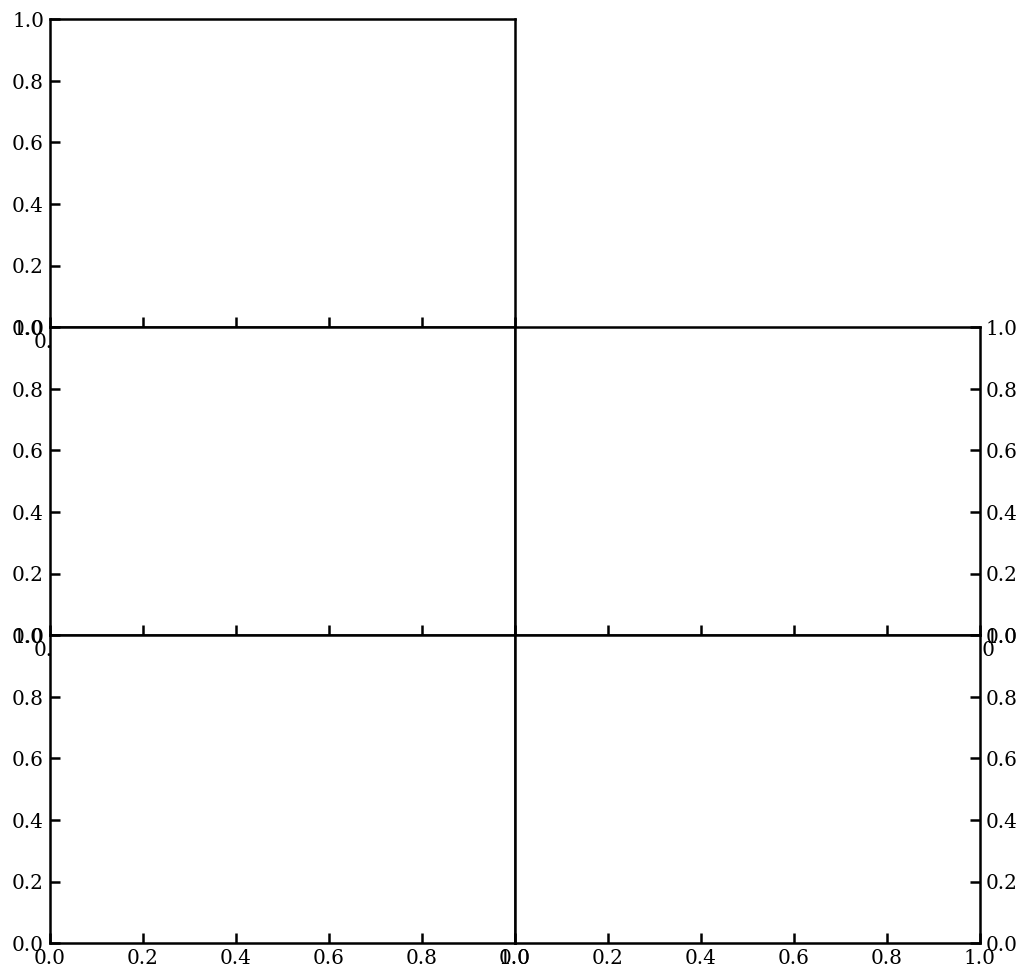

In [7]:
from scipy.interpolate import interp1d
class DataProcessingandPlot():
    def __init__(self, cores, num, delete_num, palettes, ticks=None, ranges=None):
        self.cores = cores
        self.delete_num = delete_num
        # print(list(self.cores.keys())[num])
        self.df_origin = self.cores[list(self.cores.keys())[num]].df
        self.y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']
        self.kind = 'cubic'  # 使用线性插值linear，更稳定, cubic更平滑, 
        self.num_points = 10000  # 统一插值点数
        self.palettes = palettes
        self.labels    = ['Meanfield', 'N&Z&J=0', 'N&Z&J=2', 'N&Z&J=4', 'N&Z&J=6', 'GCM_energy']
        self.xlabel   = r"$\beta_2$"
        self.ylabel    = "Energy (MeV)"
        self.title     = f"Isotope chain of Ca with different J"
        # 刻度
        self.ticks = ticks
        self.ranges = ranges

    def interpolated_data(self, df_origin):
            

        
        # df_copy = final_df.copy()

        # 将beta2=0的行对应的列energy_J2,4,6设为NAN
        df_origin.loc[(df_origin['beta2'] >= -self.delete_num) & (df_origin['beta2'] <= self.delete_num), ['energy_J2', 'energy_J4', 'energy_J6']] = np.nan
        # print(df_copy)


        # 获取数据
        df = df_origin.copy()
        # print(df)
        x = df['beta2'].values.astype(float)

        # 设置插值参数
        


        # 创建统一的插值网格
        x_uniform = np.linspace(x.min(), x.max(), self.num_points)

        # 存储插值结果
        interpolated_data = {'beta2': x_uniform}

        # 处理每个列
        for col in self.y_columns:
            y_data = df[col].values.astype(float)
            
            # 创建非NaN掩码
            mask = ~np.isnan(y_data)
            
            # 找到连续非NaN段的边界
            diff = np.diff(mask.astype(int))
            split_indices = np.where(diff != 0)[0] + 1
            
            # 初始化插值结果数组
            y_interp = np.full(self.num_points, np.nan)
            
            # 处理每个分段
            start_indices = [0] + split_indices.tolist()
            end_indices = split_indices.tolist() + [len(y_data)]
            
            for s, e in zip(start_indices, end_indices):
                if s >= e:
                    continue
                    
                seg_x = x[s:e]
                seg_y = y_data[s:e]
                if np.all(np.isnan(seg_y)):
                    continue
                
                # 单点段直接赋值
                if len(seg_x) == 1:
                    idx = np.argmin(np.abs(x_uniform - seg_x[0]))
                    y_interp[idx] = seg_y[0]
                    continue
                    
                # 创建插值函数
                f = interp1d(seg_x, seg_y, kind=self.kind, bounds_error=False, fill_value=np.nan)
                
                # 在当前分段范围内插值
                segment_mask = (x_uniform >= seg_x.min()) & (x_uniform <= seg_x.max())
                y_interp[segment_mask] = f(x_uniform[segment_mask])
            
            # 存储插值结果
            interpolated_data[col] = y_interp
        return interpolated_data
    
    def plot_package(self, text, figsize):

        interpolated_data = self.interpolated_data(self.df_origin)
        # 创建插值后的DataFrame
        final_df = pd.DataFrame(interpolated_data)

        df_origin = self.df_origin.copy()
        df_copy = final_df.copy()

        x = df_copy['beta2'].values.astype(float)
        # y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']

        # save_path_plus = f"{save_path}/{name}_positive_beta2_energy_curve.png"

        # 绘图，beta2作为x轴，Etot，energy_J0, energy_J2,energy_J4,energy_J6作为y轴, 绘制于同一附图中。颜色和线条配置采用palettes.group6和palettes.linestyles
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.family'] = 'serif'

        # 假设你的数据框是 merged_nodio_plus
        merged = df_copy.copy()   # 建议 copy 避免 SettingWithCopyWarning

        # 颜色 / 线型
        # 1. 决定总共几条线、哪些要重点突出
        total_lines = 5
        highlight = [1]          # 第0条和第2条要最显眼（从0开始数）

        # 2. 自动获取颜色和线型（默认用蓝色系）
        colors, linestyles = palettes.auto_for_lines(
            total_lines=total_lines,
            highlight_indices=highlight,
            prefer_hue="red"       # 可以改成 "green"、"red"、"purple" 等
        )

        # colors = palettes.nature5

        # linestyles = palettes.linestyles

        fontsize = 24
        # 不加粗
        fontweight = "normal"
        # fontweight = "bold" # 不加粗单词  加粗    斜体

        plt.figure(figsize=figsize, dpi=120)
        # 遍历每条曲线
        for i, y_col in enumerate(self.y_columns):
                # 获取当前列的数值数据（注意转换为 float 避免类型错误）
                y_data = merged[y_col].astype(float).values
                # print(type(merged))
                # 绘制平滑曲线（如果需要插值）
                plt.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=2.4,
                        alpha=0.95,
                        label=self.labels[i])
                # print(type(df_origin))

        # x = df_origin['beta2'].values.astype(float)
        # for i, y_col in enumerate(self.y_columns):
        #         y_data = df_origin[y_col].astype(float).values
        #         # print(len(y_data))
        #         # 叠加原始数据点（黑色小圆点）
        #         plt.scatter(x, y_data,
        #                 color='black',
        #                 s=35,
        #                 edgecolor='white',
        #                 linewidth=0.8,
        #                 zorder=10,
        #                 alpha=0.9)

        plt.ylabel(self.ylabel, fontsize=fontsize, fontweight=fontweight)
        plt.xlabel(self.xlabel, fontsize=fontsize, fontweight=fontweight)
        plt.title(self.title, fontsize=fontsize, fontweight=fontweight, pad=15)

        

        plt.legend(fontsize=13, loc='best', frameon=True, shadow=True, fancybox=True)

        if text:
            plt.annotate(text, 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8))

        # 黑色强调实验值（如果你有实验点，可在这里额外画）
        # plt.scatter(beta2_exp, Etot_exp, color='red', s=80, marker='*', zorder=20, label='Exp.')
        # print(colors)
        plt.tight_layout()

    def plot_multiple_subplots(self, num_rows:int=3, num_cols:int=3, figsize=(10, 10), sub_ax_locations_list=[(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)]):
        """
        num_rows: int, number of rows in the grid
        num_cols: int, number of columns in the grid
        figsize: tuple, size of the figure
        sub_ax_locations_list: list[tuples],list of tuples, each tuple represents the location of a subplot in the grid
        """
        # 创建子图网格
        fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize, dpi=120)
        axes[0, 1].axis('off')
        # print(type(axes[1][1]))
        # 确保axes 是一个二维数组
        if num_rows == 1 and num_cols == 1:
            axes = np.array([[axes]])
        elif num_rows == 1:
            # 将一维数组转换为二维数组，通过reshape方法实现， -1表示自动计算列数
            axes = axes.reshape(1, -1)
        elif num_cols == 1:
            axes = axes.reshape(-1, 1)
        
        # 第一列子图共享x轴
        for ax in axes[:, 0]:
            ax.sharex(axes[0, 0])
        
        # 第二列子图共享x轴
        for ax in axes[:, 1][:2]:
            ax.sharex(axes[0, 1])
        
        # ---------------------- 3. 调整子图间距（紧密相邻） ----------------------
        fig.subplots_adjust(
            hspace=0,   # 垂直方向无间距
            wspace=0 # 水平方向留极小间距（避免线条重叠，可根据需求调整）
        )  
        
        # ---------------------- 4. 控制y轴分辨率（刻度数量） ----------------------
        
        for ax in axes.flatten():  # 遍历所有子图（含隐藏的，需判断是否可见）
            
            if ax.get_visible():  # 仅处理可见子图

                # 限制y轴显示5个刻度（自动计算间隔，数值越小分辨率越高）
                ax.tick_params(axis='both', direction='in')
                ax.tick_params(
                                axis='both',
                                which='minor',    # 只改辅刻度
                                direction='in',   # 辅刻度也朝内
                                length=4,        # 辅刻度线更短（默认比主刻度短）
                                width=1,          # 辅刻度线更细
                                colors='gray'     # 辅刻度线颜色（可选，弱化视觉）
                            )
                import matplotlib.ticker as ticker
                # ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                # ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                
                # ax.locator_params(axis='y', nbins=6) 
        # ---------------------- 5. 右列y轴标签居右 ----------------------
        for i in range(3):  # 遍历右列（列索引j=1）的所有行
            ax = axes[i, 1]
            ax.yaxis.set_label_position("right")  # 将y轴标签移到右侧
            ax.tick_params(axis='y', which='both', left=False, right=True, labelleft=False, labelright=True)  # 刻度标签也显示在右侧
            # ax.tick_params(axis='y', which='both', direction='in')


        # 遍历每个子图
        for idx, core_id in enumerate(self.cores):
            # row = idx // num_cols
            # col = idx % num_cols
            row, col = sub_ax_locations_list[idx]
            # 声明row, col的类型
            row, col = int(row), int(col)
            # print("row, col: ", row, col)
            ax = axes[row, col]
            # ax.set_xlim() # 设置x轴范围
            # ax.set_ylim() # 设置y轴范围
           
                              
            # 获取当前子图的数据
            # print("core_id: ", core_id)
            # print("original_df: ", cores)
            original_df = cores[core_id].df.copy()
            interpolated_data = self.interpolated_data(original_df)
            gcm_energy = cores[core_id].gcm_energy
            finally_df = pd.DataFrame(interpolated_data)
            if self.ranges:
                
                max_y, min_y = self.ranges[idx]
            else:
                max_y = max(list(finally_df[self.y_columns].max()))
                min_y = min(list(finally_df[self.y_columns].min()))
            resolution = (max_y - min_y)/5
            # print("max_y: ", max_y)
            # print("min_y: ", min_y)
            # print("resolution: ", resolution)
            # engraving_degree = int((max_y - min_y)/resolution)
            # 直接设置 y 轴范围（留一点上下边距）
            margin = (max_y - min_y) * 0.08          # 8% 边距，可调小到 0.05 或 0.1
            ax.set_ylim(min_y - margin, max_y + margin) # 设置 y 轴范围, 第一个参数控制

            # 让 matplotlib 自动决定刻度数量和位置（通常很美观）
            ax.locator_params(axis='y', nbins=5)     # 目标显示约6个主刻度，可改成5~8
            # print(max_y, min_y, engraving_degree)
            # ax.locator_params(axis='y', nbins=engraving_degree)
            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=4))
            ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
            # print(interpolated_data)

            # 1. 决定总共几条线、哪些要重点突出
            # total_lines = 5
            highlight = [1]          # 第1条要最显眼（从0开始数）
            sub_highlight = [0, 2, 3, 4]

            # 2. 自动获取颜色和线型（默认用蓝色系）
            # colors, linestyles = palettes.auto_for_lines(
            #     total_lines=total_lines,
            #     highlight_indices=highlight,
            #     prefer_hue="black"       # 可以改成 "green"、"red"、"purple" 等
            # )
            # colors = palettes.nature5withblack
            # linestyles = palettes.linestyles
            colors, linestyles = palettes.get_all_colors_linestyles(
                                                    total=len(self.y_columns),
                                                    emphasize_indices=highlight,
                                                    sub_emphasize_indices=sub_highlight   # 可以为空
                                                )


            # 绘制插值曲线
            x = finally_df['beta2'].values.astype(float)
            # print(self.palettes.nature5,'\n', colors)
            for i, y_col in enumerate(self.y_columns):
                y_data = finally_df[y_col].astype(float).values
                
                ax.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=2.4,
                        alpha=0.95,
                        label=self.labels[i]
                        )
            # x_orig = original_df['beta2'].values.astype(float)
            # for i, y_col in enumerate(self.y_columns):
            #     y_data = original_df[y_col].astype(float).values
            #     ax.scatter(x_orig, y_data,
            #             color='black',
            #             s=35,
            #             edgecolor='white',
            #             linewidth=0.8,
            #             zorder=10,
            #             alpha=0.9)
            # 7. 设置子图标题（仅显示核编号）
            # ax.set_title(f"Core {core_id}", fontsize=14, fontweight='bold')
            # print(core_id)
            ax.annotate(f"$^{{{core_id[0:2]}}}${core_id[2:4]}", 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8), zorder=200)
            # 假设你想在 beta2 = 0.0 处标注这个值
            x_pos = 0.0          # 你想放短线的位置
            marked_value = gcm_energy
            half_length = 0.04   # 短线左右各延伸多少（单位是 beta2）

            # 画短横线
            # ax.hlines(
            #     y=marked_value,
            #     xmin=x_pos - half_length,
            #     xmax=x_pos + half_length,
            #     colors='red',
            #     linewidth=2.5,
            #     zorder=15
            # )
            # 用 plot 画短横线（这样就能正常进 legend）
            ax.plot(
                [x_pos - half_length, x_pos + half_length], 
                [marked_value, marked_value],
                color='red',
                linewidth=2.0,
                solid_capstyle='butt',   # 让线端平直，更像 hlines
                label=f'GCM Ground E'   # ← 这里给 label 就行了
            )
            
            # 8. 添加图例（只在某一个子图显示）
            if row == 1 and col == 1:
                ax.legend(
                fontsize=10.5,
                loc='center',
                # ncol=5,                    # 横向排列
                frameon=True,
                fancybox=True,
                shadow=False,
                bbox_to_anchor=(0.5, 1.6),  # 稍微向上一点，避免太贴底
            )
            
            if row == 2:
                # 设置x坐标，标题
                ax.set_xlabel(self.xlabel, fontsize=20, fontweight='normal')
        
        # # ─── 在循环外面统一画一次 legend ───
        # hidden_ax = axes[0, 1]           # 右下角隐藏的那个 ax

        # # 先收集所有 label（其实你所有子图的 label 都一样，所以取任何一个 ax 都行）
        # # 但最稳妥的方式是直接用你已经定义好的 self.labels
        # hidden_ax.legend(
        #         fontsize=10.5,
        #         loc='center',
        #         ncol=5,                    # 横向排列
        #         frameon=True,
        #         fancybox=True,
        #         shadow=True,
        #         bbox_to_anchor=(0.5, 0.55),  # 稍微向上一点，避免太贴底
        #     )
                

            

        fontweight = "normal"        
        # 11. 添加全局标题和标签
        # fig.suptitle(self.title, fontsize=20, fontweight=fontweight, y=0.92) # y参数调整标题位置
        # fig.supxlabel(self.xlabel, fontsize=20, fontweight=fontweight, y=0.05)
        fig.supylabel(self.ylabel, fontsize=20, fontweight=fontweight, x=0.04)

        # 13. 调整布局
        # plt.tight_layout(rect=[0, 0, 1, 0.98]) # 为全局标题留空间

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -364),
    (-370, -384),
    (-388, -401),
    (-402, -416)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
palettes = TopJournalPalettes()
# 删除掉第二个元素
if len(cores) > 5:
    cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
dpap = DataProcessingandPlot(cores, 1, 0.1, palettes, ticks=None, ranges=ranges)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


# 第二段绘制代码

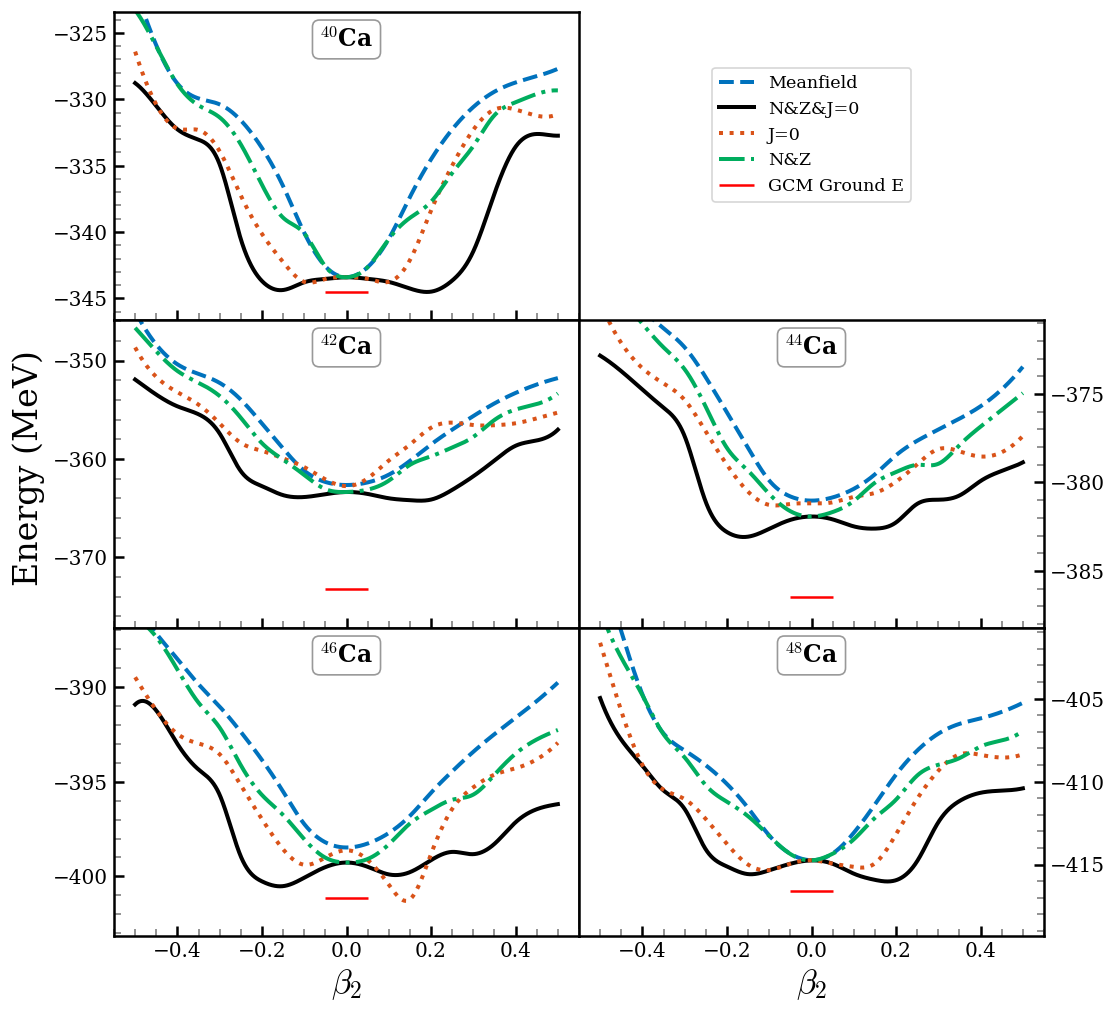

In [16]:
from scipy.interpolate import interp1d
class DataProcessingandPlot():
    def __init__(
            self, cores, num, delete_num, palettes, 
            y_columns=['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6'],
            labels=['Meanfield', 'N&Z&J=0', 'N&Z&J=2', 'N&Z&J=4', 'N&Z&J=6', 'GCM_energy'],
            inter_method='cubic',
            xlabel=r"$\beta_2$",
            ylabel="Energy (MeV)",
            title="Isotope chain of Ca with different J",
            ticks=None, ranges=None):
        self.cores = cores
        self.delete_num = delete_num
        # print(list(self.cores.keys())[num])
        self.df_origin = self.cores["40Ca"].df
        self.y_columns = y_columns
        self.kind = inter_method  # 使用线性插值linear，更稳定, cubic更平滑, 
        self.num_points = 10000  # 统一插值点数
        self.palettes = palettes
        self.labels    = labels
        self.xlabel   = xlabel
        self.ylabel    = ylabel
        self.title     = title
        # 刻度
        self.ticks = ticks
        self.ranges = ranges

    def interpolated_data(self, df_origin):
            

        
        # df_copy = final_df.copy()

        # 将beta2=0的行对应的列energy_J2,4,6设为NAN
        df_origin.loc[(df_origin['beta2'] >= -self.delete_num) & (df_origin['beta2'] <= self.delete_num), ['energy_J2', 'energy_J4', 'energy_J6']] = np.nan
        # print(df_copy)


        # 获取数据
        df = df_origin.copy()
        # print(df)
        x = df['beta2'].values.astype(float)

        # 设置插值参数
        


        # 创建统一的插值网格
        x_uniform = np.linspace(x.min(), x.max(), self.num_points)

        # 存储插值结果
        interpolated_data = {'beta2': x_uniform}

        # 处理每个列
        for col in self.y_columns:
            y_data = df[col].values.astype(float)
            
            # 创建非NaN掩码
            mask = ~np.isnan(y_data)
            
            # 找到连续非NaN段的边界
            diff = np.diff(mask.astype(int))
            split_indices = np.where(diff != 0)[0] + 1
            
            # 初始化插值结果数组
            y_interp = np.full(self.num_points, np.nan)
            
            # 处理每个分段
            start_indices = [0] + split_indices.tolist()
            end_indices = split_indices.tolist() + [len(y_data)]
            
            for s, e in zip(start_indices, end_indices):
                if s >= e:
                    continue
                    
                seg_x = x[s:e]
                seg_y = y_data[s:e]
                if np.all(np.isnan(seg_y)):
                    continue
                
                # 单点段直接赋值
                if len(seg_x) == 1:
                    idx = np.argmin(np.abs(x_uniform - seg_x[0]))
                    y_interp[idx] = seg_y[0]
                    continue
                    
                # 创建插值函数
                f = interp1d(seg_x, seg_y, kind=self.kind, bounds_error=False, fill_value=np.nan)
                
                # 在当前分段范围内插值
                segment_mask = (x_uniform >= seg_x.min()) & (x_uniform <= seg_x.max())
                y_interp[segment_mask] = f(x_uniform[segment_mask])
            
            # 存储插值结果
            interpolated_data[col] = y_interp
        return interpolated_data
    
    def plot_package(self, text, figsize):

        interpolated_data = self.interpolated_data(self.df_origin)
        # 创建插值后的DataFrame
        final_df = pd.DataFrame(interpolated_data)

        df_origin = self.df_origin.copy()
        df_copy = final_df.copy()

        x = df_copy['beta2'].values.astype(float)
        # y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']

        # save_path_plus = f"{save_path}/{name}_positive_beta2_energy_curve.png"

        # 绘图，beta2作为x轴，Etot，energy_J0, energy_J2,energy_J4,energy_J6作为y轴, 绘制于同一附图中。颜色和线条配置采用palettes.group6和palettes.linestyles
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.family'] = 'serif'

        # 假设你的数据框是 merged_nodio_plus
        merged = df_copy.copy()   # 建议 copy 避免 SettingWithCopyWarning

        # 颜色 / 线型
        # 1. 决定总共几条线、哪些要重点突出
        total_lines = 5
        highlight = [1]          # 第0条和第2条要最显眼（从0开始数）

        # 2. 自动获取颜色和线型（默认用蓝色系）
        colors, linestyles = palettes.auto_for_lines(
            total_lines=total_lines,
            highlight_indices=highlight,
            prefer_hue="red"       # 可以改成 "green"、"red"、"purple" 等
        )

        # colors = palettes.nature5

        # linestyles = palettes.linestyles

        fontsize = 24
        # 不加粗
        fontweight = "normal"
        # fontweight = "bold" # 不加粗单词  加粗    斜体

        plt.figure(figsize=figsize, dpi=120)
        # 遍历每条曲线
        for i, y_col in enumerate(self.y_columns):
                # 获取当前列的数值数据（注意转换为 float 避免类型错误）
                y_data = merged[y_col].astype(float).values
                # print(type(merged))
                # 绘制平滑曲线（如果需要插值）
                plt.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=2.4,
                        alpha=0.95,
                        label=self.labels[i])
                # print(type(df_origin))

        # x = df_origin['beta2'].values.astype(float)
        # for i, y_col in enumerate(self.y_columns):
        #         y_data = df_origin[y_col].astype(float).values
        #         # print(len(y_data))
        #         # 叠加原始数据点（黑色小圆点）
        #         plt.scatter(x, y_data,
        #                 color='black',
        #                 s=35,
        #                 edgecolor='white',
        #                 linewidth=0.8,
        #                 zorder=10,
        #                 alpha=0.9)

        plt.ylabel(self.ylabel, fontsize=fontsize, fontweight=fontweight)
        plt.xlabel(self.xlabel, fontsize=fontsize, fontweight=fontweight)
        plt.title(self.title, fontsize=fontsize, fontweight=fontweight, pad=15)

        

        plt.legend(fontsize=13, loc='best', frameon=True, shadow=True, fancybox=True)

        if text:
            plt.annotate(text, 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8))

        # 黑色强调实验值（如果你有实验点，可在这里额外画）
        # plt.scatter(beta2_exp, Etot_exp, color='red', s=80, marker='*', zorder=20, label='Exp.')
        # print(colors)
        plt.tight_layout()

    def plot_multiple_subplots(self, num_rows:int=3, num_cols:int=3, figsize=(10, 10), sub_ax_locations_list=[(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)]):
        """
        num_rows: int, number of rows in the grid
        num_cols: int, number of columns in the grid
        figsize: tuple, size of the figure
        sub_ax_locations_list: list[tuples],list of tuples, each tuple represents the location of a subplot in the grid
        """
        # 创建子图网格
        fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize, dpi=120)
        axes[0, 1].axis('off')
        # print(type(axes[1][1]))
        # 确保axes 是一个二维数组
        if num_rows == 1 and num_cols == 1:
            axes = np.array([[axes]])
        elif num_rows == 1:
            # 将一维数组转换为二维数组，通过reshape方法实现， -1表示自动计算列数
            axes = axes.reshape(1, -1)
        elif num_cols == 1:
            axes = axes.reshape(-1, 1)
        
        # 第一列子图共享x轴
        for ax in axes[:, 0]:
            ax.sharex(axes[0, 0])
        
        # 第二列子图共享x轴
        for ax in axes[:, 1][:2]:
            ax.sharex(axes[0, 1])
        
        # ---------------------- 3. 调整子图间距（紧密相邻） ----------------------
        fig.subplots_adjust(
            hspace=0,   # 垂直方向无间距
            wspace=0 # 水平方向留极小间距（避免线条重叠，可根据需求调整）
        )  
        
        # ---------------------- 4. 控制y轴分辨率（刻度数量） ----------------------
        
        for ax in axes.flatten():  # 遍历所有子图（含隐藏的，需判断是否可见）
            
            if ax.get_visible():  # 仅处理可见子图

                # 限制y轴显示5个刻度（自动计算间隔，数值越小分辨率越高）
                ax.tick_params(axis='both', direction='in')
                ax.tick_params(
                                axis='both',
                                which='minor',    # 只改辅刻度
                                direction='in',   # 辅刻度也朝内
                                length=4,        # 辅刻度线更短（默认比主刻度短）
                                width=1,          # 辅刻度线更细
                                colors='gray'     # 辅刻度线颜色（可选，弱化视觉）
                            )
                import matplotlib.ticker as ticker
                # ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                # ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                
                # ax.locator_params(axis='y', nbins=6) 
        # ---------------------- 5. 右列y轴标签居右 ----------------------
        for i in range(3):  # 遍历右列（列索引j=1）的所有行
            ax = axes[i, 1]
            ax.yaxis.set_label_position("right")  # 将y轴标签移到右侧
            ax.tick_params(axis='y', which='both', left=False, right=True, labelleft=False, labelright=True)  # 刻度标签也显示在右侧
            # ax.tick_params(axis='y', which='both', direction='in')


        # 遍历每个子图
        for idx, core_id in enumerate(self.cores):
            # row = idx // num_cols
            # col = idx % num_cols
            row, col = sub_ax_locations_list[idx]
            # 声明row, col的类型
            row, col = int(row), int(col)
            # print("row, col: ", row, col)
            ax = axes[row, col]
            # ax.set_xlim() # 设置x轴范围
            # ax.set_ylim() # 设置y轴范围
           
                              
            # 获取当前子图的数据
            # print("core_id: ", core_id)
            # print("original_df: ", cores)
            original_df = cores[core_id].df.copy()
            interpolated_data = self.interpolated_data(original_df)
            gcm_energy = cores[core_id].gcm_energy
            finally_df = pd.DataFrame(interpolated_data)
            if self.ranges:
                
                max_y, min_y = self.ranges[idx]
            else:
                max_y = max(list(finally_df[self.y_columns].max()))
                min_y = min(list(finally_df[self.y_columns].min()))
            resolution = (max_y - min_y)/5
            # print("max_y: ", max_y)
            # print("min_y: ", min_y)
            # print("resolution: ", resolution)
            # engraving_degree = int((max_y - min_y)/resolution)
            # 直接设置 y 轴范围（留一点上下边距）
            margin = (max_y - min_y) * 0.08          # 8% 边距，可调小到 0.05 或 0.1
            ax.set_ylim(min_y - margin, max_y + margin) # 设置 y 轴范围, 第一个参数控制

            # 让 matplotlib 自动决定刻度数量和位置（通常很美观）
            ax.locator_params(axis='y', nbins=5)     # 目标显示约6个主刻度，可改成5~8
            # print(max_y, min_y, engraving_degree)
            # ax.locator_params(axis='y', nbins=engraving_degree)
            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=4))
            ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
            # print(interpolated_data)

            # 1. 决定总共几条线、哪些要重点突出
            # total_lines = 5
            highlight = [1]          # 第1条要最显眼（从0开始数）
            sub_highlight = [0, 2, 3]

            # 2. 自动获取颜色和线型（默认用蓝色系）
            # colors, linestyles = palettes.auto_for_lines(
            #     total_lines=total_lines,
            #     highlight_indices=highlight,
            #     prefer_hue="black"       # 可以改成 "green"、"red"、"purple" 等
            # )
            # colors = palettes.nature5withblack
            # linestyles = palettes.linestyles
            colors, linestyles = palettes.get_all_colors_linestyles(
                                                    total=len(self.y_columns),
                                                    emphasize_indices=highlight,
                                                    sub_emphasize_indices=sub_highlight   # 可以为空
                                                )


            # 绘制插值曲线
            x = finally_df['beta2'].values.astype(float)
            # print(self.palettes.nature5,'\n', colors)
            for i, y_col in enumerate(self.y_columns):
                y_data = finally_df[y_col].astype(float).values
                
                ax.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=2.4,
                        alpha=1,
                        label=self.labels[i]
                        )
            # x_orig = original_df['beta2'].values.astype(float)
            # for i, y_col in enumerate(self.y_columns):
            #     y_data = original_df[y_col].astype(float).values
            #     ax.scatter(x_orig, y_data,
            #             color='black',
            #             s=35,
            #             edgecolor='white',
            #             linewidth=0.8,
            #             zorder=10,
            #             alpha=0.9)
            # 7. 设置子图标题（仅显示核编号）
            # ax.set_title(f"Core {core_id}", fontsize=14, fontweight='bold')
            # print(core_id)
            ax.annotate(f"$^{{{core_id[0:2]}}}${core_id[2:4]}", 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8), zorder=200)
            # 假设你想在 beta2 = 0.0 处标注这个值
            x_pos = 0.0          # 你想放短线的位置
            marked_value = gcm_energy
            half_length = 0.05   # 短线左右各延伸多少（单位是 beta2）

            # 画短横线
            # ax.hlines(
            #     y=marked_value,
            #     xmin=x_pos - half_length,
            #     xmax=x_pos + half_length,
            #     colors='red',
            #     linewidth=2.5,
            #     zorder=15
            # )
            # 用 plot 画短横线（这样就能正常进 legend）
            ax.plot(
                [x_pos - half_length, x_pos + half_length], 
                [marked_value, marked_value],
                color='red',
                linewidth=1.5,
                solid_capstyle='butt',   # 让线端平直，更像 hlines
                label=f'GCM Ground E'   # ← 这里给 label 就行了
            )
            
            # 8. 添加图例（只在某一个子图显示）
            if row == 1 and col == 1:
                ax.legend(
                fontsize=10.5,
                loc='center',
                # ncol=5,                    # 横向排列
                frameon=True,
                fancybox=True,
                shadow=False,
                bbox_to_anchor=(0.5, 1.6),  # 稍微向上一点，避免太贴底
            )
            
            if row == 2:
                # 设置x坐标，标题
                ax.set_xlabel(self.xlabel, fontsize=20, fontweight='normal')
        
        # # ─── 在循环外面统一画一次 legend ───
        # hidden_ax = axes[0, 1]           # 右下角隐藏的那个 ax

        # # 先收集所有 label（其实你所有子图的 label 都一样，所以取任何一个 ax 都行）
        # # 但最稳妥的方式是直接用你已经定义好的 self.labels
        # hidden_ax.legend(
        #         fontsize=10.5,
        #         loc='center',
        #         ncol=5,                    # 横向排列
        #         frameon=True,
        #         fancybox=True,
        #         shadow=True,
        #         bbox_to_anchor=(0.5, 0.55),  # 稍微向上一点，避免太贴底
        #     )
                

            

        fontweight = "normal"        
        # 11. 添加全局标题和标签
        # fig.suptitle(self.title, fontsize=20, fontweight=fontweight, y=0.92) # y参数调整标题位置
        # fig.supxlabel(self.xlabel, fontsize=20, fontweight=fontweight, y=0.05)
        fig.supylabel(self.ylabel, fontsize=20, fontweight=fontweight, x=0.04)

        # 13. 调整布局
        # plt.tight_layout(rect=[0, 0, 1, 0.98]) # 为全局标题留空间

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -375),
    (-372, -387),
    (-388, -402),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J011', 'energy_J010', 'energy_J001']
labels=['Meanfield', 'N&Z&J=0', 'J=0', 'N&Z', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
cores = core_dict
dpap = DataProcessingandPlot(cores, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


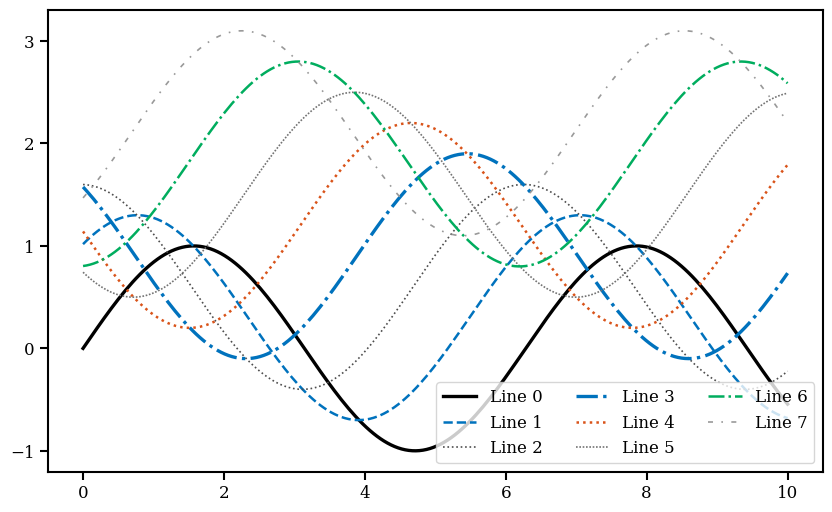

In [22]:
from topJournalPalettes import TopJournalPalettes
palettes = TopJournalPalettes()

# 示例1：总共8条线，第0、3条是强调，第1、4、6是次强调，其余为背景
colors, linestyles = palettes.get_all_colors_linestyles(
    total=8,
    emphasize_indices=[0, 3],
    sub_emphasize_indices=[1, 4, 6]
)

# # 示例2：只强调前两条，其余都是背景
# colors, linestyles = palettes.get_all_colors_linestyles(
#     total=10,
#     emphasize_indices=[0, 1],
#     sub_emphasize_indices=[]   # 可以为空
# )

# 画图示例
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 200)
plt.figure(figsize=(10, 6))
for i in range(len(colors)):
    y = np.sin(x + i * 0.8) + i * 0.3
    plt.plot(x, y, color=colors[i], ls=linestyles[i],
            lw=2.4 if i in [0,3] else 1.8 if i in [1,4,6] else 1.2,
            label=f'Line {i}')
plt.legend(ncol=3)
plt.show()

In [23]:
elements = ["Ca"]
element = elements[0]
# The rule of naming: A + n0f + pnp + nbeta
A = 40
As = [41, 43, 45, 47, 49]
# As = [42]
n0fs = [6]
pnps = [111]   # project of particle number or not
nbetas = [20,12]
cores = {}
save_path = f"results/{A}{element}/pictures"
isbindingenergypositive = False
for element in elements:
    for A in As:
        for n0f in n0fs:
            for pnp in pnps:
                for nbeta in nbetas:
                    # 检查待载入的文件是否存在,dataprocessing/results/40Ca/40Ca_6_110_12/40Ca_6_110_12_kern_data.csv
                    core = CoreManager(A, element, n0f, pnp, nbeta)
                    if os.path.exists(core.save_path) and os.path.exists(core.file_path):
                        if isbindingenergypositive:
                            # df_temp = dataprocessing(core.path, core.file_path, core.cvn, core.save_path)
                            df_temp[['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']] = df_temp[['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']].abs()
                            # print(df_temp)
                            core.getdata(df_temp)
                            # print(core.df)
                            cores[core.ID] = core
                        else:
                            # core.getdata(dataprocessing(core.path, core.file_path, core.cvn, core.save_path))
                            cores[core.ID] = core

one_core_data = []
for classes, core in cores.items():
    # print(core)
    one_core_data.append(core.df)
# variable = ["beta2",'beta3', 'Etot']

# print(cores['6_111_12'].df)
# 合并数据集
temp_list = list(cores.keys()) # 获取键
print(temp_list)

[]


In [24]:
import os
As = [41, 43, 45, 47, 49]
n0f = 6
pnp = 111
element = 'Ca'
nbeta = 20
# 打印工作目录
for A in As:
    core = CoreManager(A, element, n0f, pnp, nbeta)
    cores[core.ID] = core
    file_path = f"../datas/{A}{element}_{n0f}{pnp}{nbeta}/output/CDFT_Expectation.out"
    df_d = pd.read_csv(
        file_path,
        sep=r"\s+",          # 匹配任意空白字符（空格/制表符）
        header=0,           # 第一行作为列名
        names=[             # 显式指定列名（可选，若文件无表头时使用）
            "iteration", "eps", "beta2", "beta3",
            "beta2_calculate", "beta3_calculate", 
            "Etot", "Erot", "Etot-Erot", 
            "rms-Radius", "charge-Radius"
        ],
        dtype={
            "iteration": int,
            "eps": float,
            "beta2": float,
            "beta3": float,
            "beta2_calculate": float,
            "beta3_calculate": float,
            "Etot": float,
            "Erot": float,
            "Etot-Erot": float,
            "rms-Radius": float,
            "charge-Radius": float
        },
        na_values=["NA", "NaN"]  # 处理可能的缺失值标记
    )
    df_dd = df_d.drop(columns=["iteration", "eps","beta2_calculate", "beta3_calculate", "rms-Radius", "Etot-Erot","Erot"])
    # print(df_dd)
    core.getdata(df_dd)
# 最健壮的解决方案
def get_nuclear_number(key):
    """从核素键中提取质量数（如40Ca中的40）"""
    return int(''.join(takewhile(str.isdigit, key)))

# 需要导入
from itertools import takewhile

# 排序
temp_list = sorted(cores.keys(), key=get_nuclear_number)
print("按核素质量数排序:", temp_list)
sorted_cores = {key: cores[key] for key in temp_list}
print(sorted_cores)

FileNotFoundError: [Errno 2] No such file or directory: '../datas/41Ca_611120/output/CDFT_Expectation.out'

In [ ]:
# cores.pop(temp_list[1])
temp_list = list(sorted_cores.keys()) # 获取键
print(temp_list)
# print(cores[temp_list[0]].df[df['beta2']==0]['Etot'])
# 提取cores[temp_list[0, 1,2,3,4]].df中的beta2列为零的行对应Etot的值
def gE(i):
    df_temp = cores[temp_list[i]].df
    # print(df_temp.head(1))
    return df_temp[df_temp['beta2']==0]['Etot']
# 重新生成一个列表df,列名为，elements(值为40Ca, 42Ca, 44Ca, 46Ca, 48Ca),meanfield(值为cores[temp_list[i]].df[df['beta2']==0]['Etot'] for i in range(len(temp_list)))
# print(gE(0))
df = pd.DataFrame({'elements': [40,41,42,43,44,45,46,47,48], 'meanfield': [gE(0), gE(1), gE(2), gE(3), gE(4), gE(5), gE(6), gE(7), gE(8)]})
print(df)
# 绘制折线图



['41Ca_6_111_20', '43Ca_6_111_20', '45Ca_6_111_20', '47Ca_6_111_20', '49Ca_6_111_20']


IndexError: list index out of range

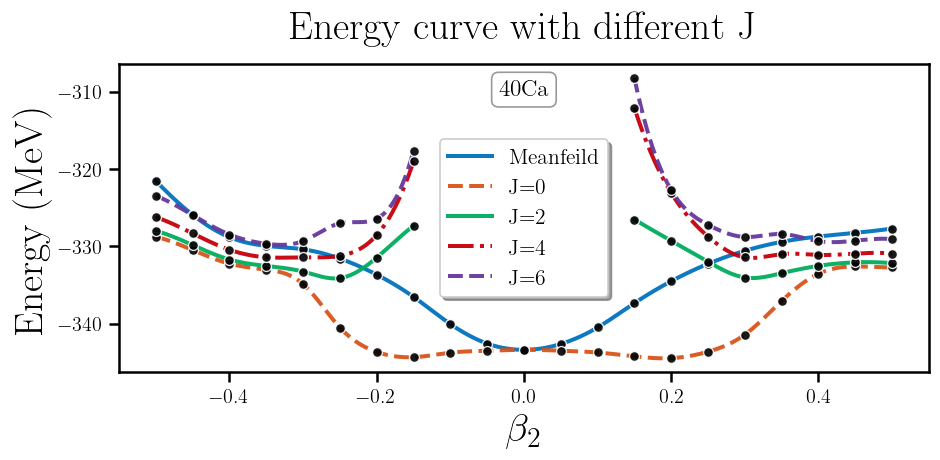

In [ ]:
plot_package("40Ca",figsize, 1)

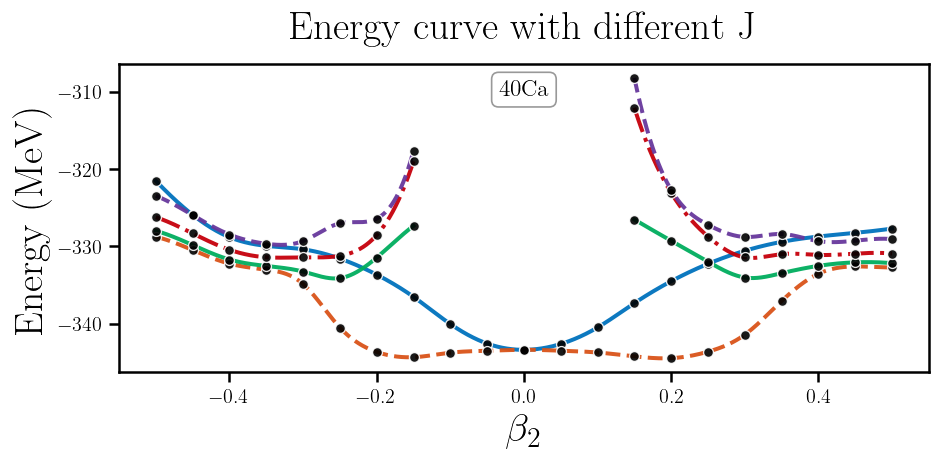

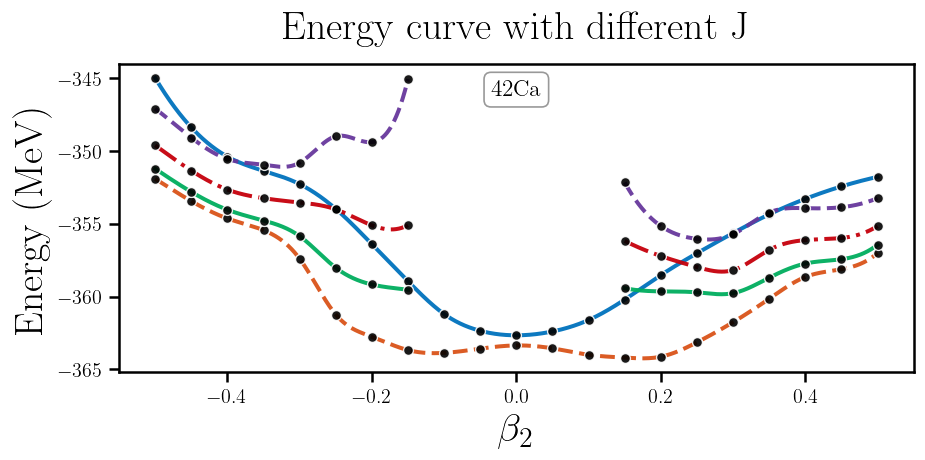

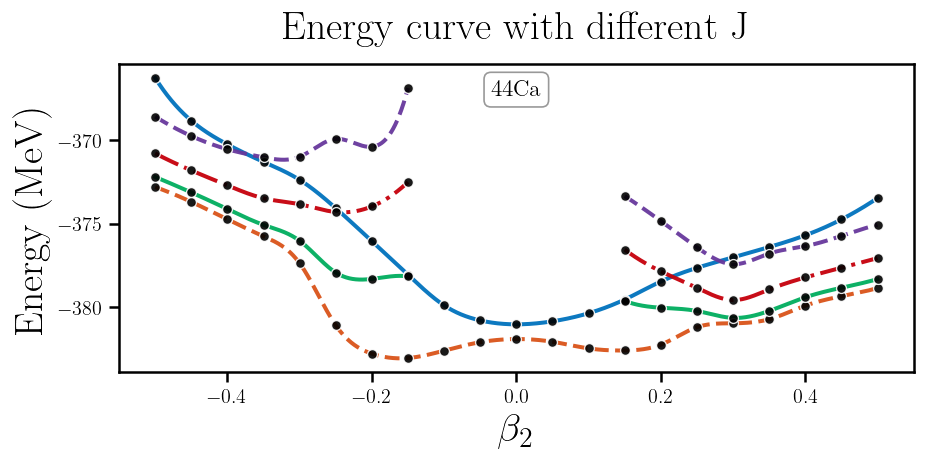

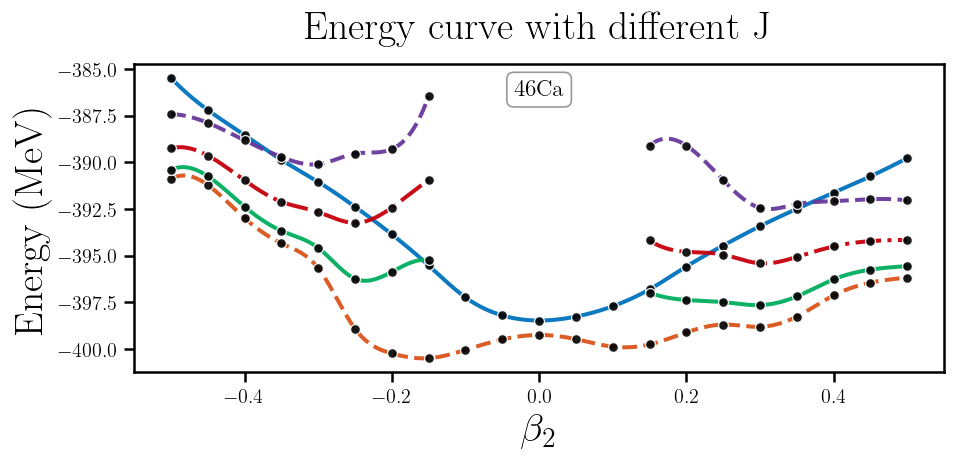

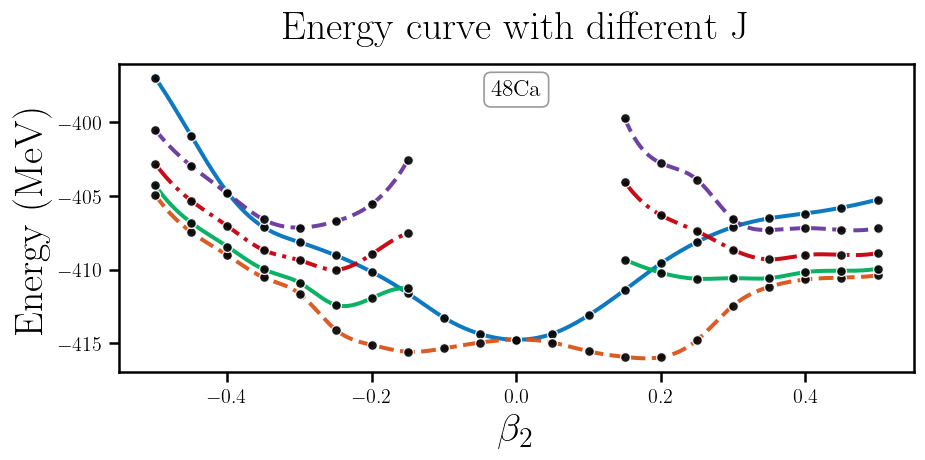

In [ ]:
# plot_package("40Ca",figsize, 1)
plot_package("42Ca",figsize, 2)
plot_package("44Ca",figsize, 3)
plot_package("46Ca",figsize, 4)
plot_package("48Ca",figsize, 5)

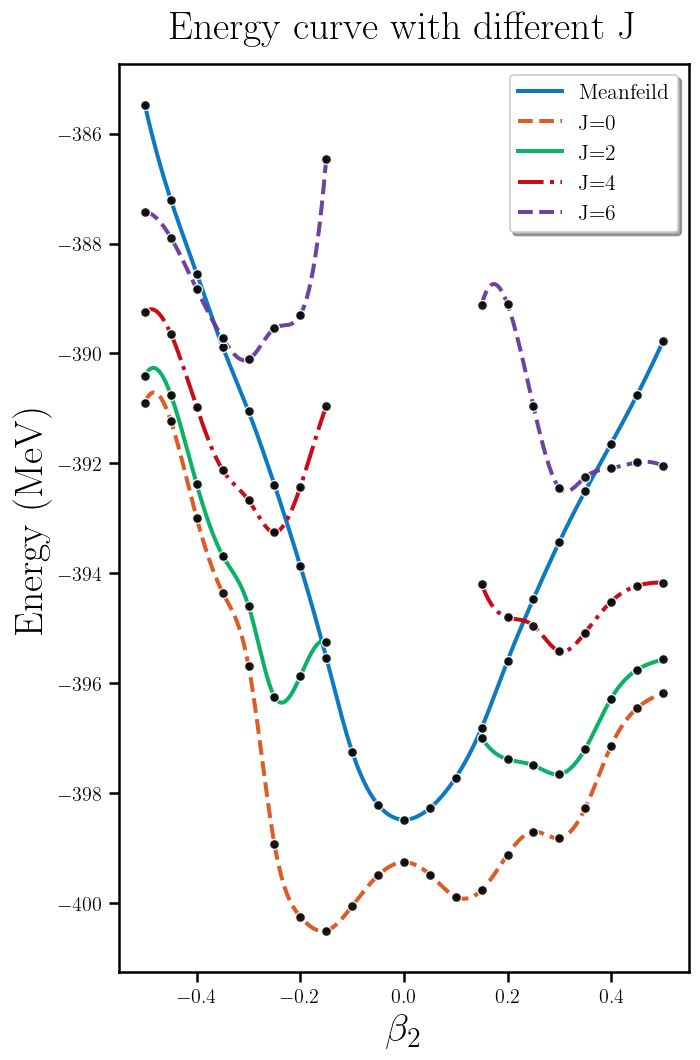

In [ ]:

from scipy.interpolate import interp1d

df_copy = cores[list(cores.keys())[2]].df
# df_copy = final_df.copy()
num = 0.1
# 将beta2=0的行对应的列energy_J2,4,6设为NAN
df_copy.loc[(df_copy['beta2'] >= -num) & (df_copy['beta2'] <= num), ['energy_J2', 'energy_J4', 'energy_J6']] = np.nan
# print(df_copy)


# 获取数据
df = df_copy
# print(df)
x = df['beta2'].values.astype(float)

# 设置插值参数
y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']
kind = 'cubic'  # 使用线性插值linear，更稳定, cubic更平滑, 
num_points = 1000000  # 统一插值点数

# 创建统一的插值网格
x_uniform = np.linspace(x.min(), x.max(), num_points)

# 存储插值结果
interpolated_data = {'beta2': x_uniform}

# 处理每个列
for col in y_columns:
    y_data = df[col].values.astype(float)
    
    # 创建非NaN掩码
    mask = ~np.isnan(y_data)
    
    # 找到连续非NaN段的边界
    diff = np.diff(mask.astype(int))
    split_indices = np.where(diff != 0)[0] + 1
    
    # 初始化插值结果数组
    y_interp = np.full(num_points, np.nan)
    
    # 处理每个分段
    start_indices = [0] + split_indices.tolist()
    end_indices = split_indices.tolist() + [len(y_data)]
    
    for s, e in zip(start_indices, end_indices):
        if s >= e:
            continue
            
        seg_x = x[s:e]
        seg_y = y_data[s:e]
        
        # 单点段直接赋值
        if len(seg_x) == 1:
            idx = np.argmin(np.abs(x_uniform - seg_x[0]))
            y_interp[idx] = seg_y[0]
            continue
            
        # 创建插值函数
        f = interp1d(seg_x, seg_y, kind=kind, bounds_error=False, fill_value=np.nan)
        
        # 在当前分段范围内插值
        segment_mask = (x_uniform >= seg_x.min()) & (x_uniform <= seg_x.max())
        y_interp[segment_mask] = f(x_uniform[segment_mask])
    
    # 存储插值结果
    interpolated_data[col] = y_interp

# 创建插值后的DataFrame
final_df = pd.DataFrame(interpolated_data)

df_origin = df.copy()
df_copy = final_df.copy()

x = df_copy['beta2'].values.astype(float)
y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']
labels    = ['Meanfeild', 'J=0', 'J=2', 'J=4', 'J=6']
xlabel   = r"$\beta_2$"
ylabel    = "Energy (MeV)"
title     = f"Energy curve with different J "
# save_path_plus = f"{save_path}/{name}_positive_beta2_energy_curve.png"

# 绘图，beta2作为x轴，Etot，energy_J0, energy_J2,energy_J4,energy_J6作为y轴, 绘制于同一附图中。颜色和线条配置采用palettes.group6和palettes.linestyles
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# 假设你的数据框是 merged_nodio_plus
merged = df_copy.copy()   # 建议 copy 避免 SettingWithCopyWarning

# 排序（非常重要！插值要求 x 单调递增）
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]

# 颜色 / 线型
colors = palettes.nature5
linestyles = palettes.linestyles

fontsize = 24
fontweight = 'bold'

plt.figure(figsize=figsize, dpi=120)
# 遍历每条曲线
for i, y_col in enumerate(y_columns):
        # 获取当前列的数值数据（注意转换为 float 避免类型错误）
        y_data = merged[y_col].astype(float).values
        # print(type(merged))
        # 绘制平滑曲线（如果需要插值）
        plt.plot(x, y_data,
                color=colors[i % len(colors)],
                linestyle=linestyles[i % len(linestyles)],
                linewidth=2.4,
                alpha=0.95,
                label=labels[i])
        # print(type(df_origin))

x = df_origin['beta2'].values.astype(float)
for i, y_col in enumerate(y_columns):
        y_data = df_origin[y_col].astype(float).values
        # print(len(y_data))
        # 叠加原始数据点（黑色小圆点）
        plt.scatter(x, y_data,
                color='black',
                s=35,
                edgecolor='white',
                linewidth=0.8,
                zorder=10,
                alpha=0.9)

plt.ylabel(ylabel, fontsize=fontsize, fontweight=fontweight)
plt.xlabel(xlabel, fontsize=fontsize, fontweight=fontweight)
plt.title(title, fontsize=fontsize, fontweight=fontweight, pad=15)

plt.legend(fontsize=13, loc='best', frameon=True, shadow=True, fancybox=True)


# 黑色强调实验值（如果你有实验点，可在这里额外画）
# plt.scatter(beta2_exp, Etot_exp, color='red', s=80, marker='*', zorder=20, label='Exp.')

plt.tight_layout()

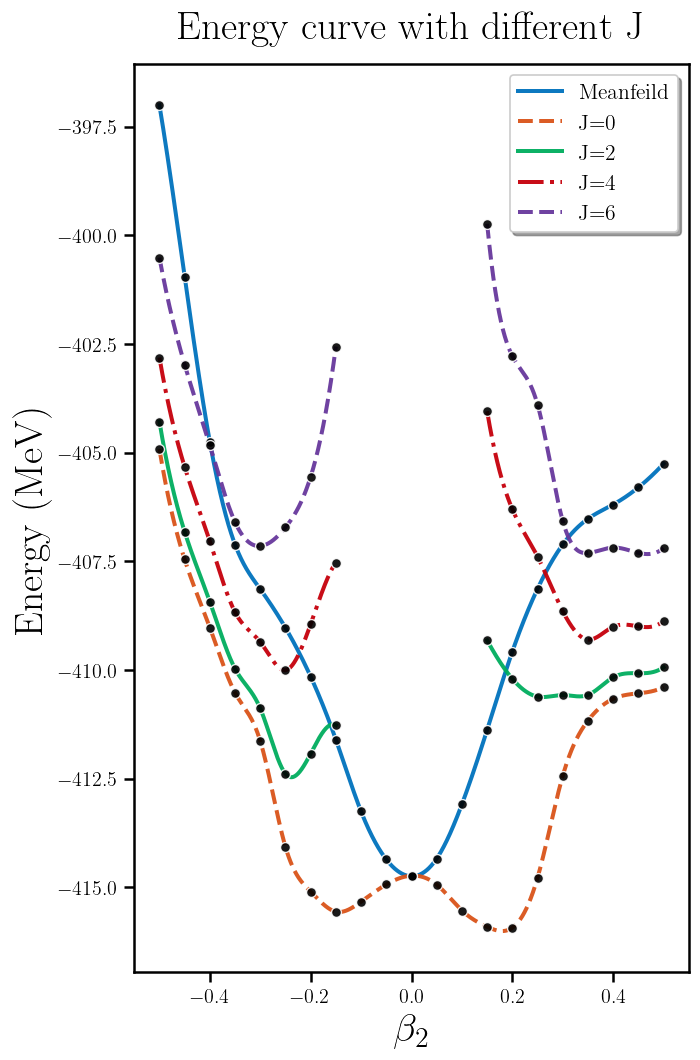

In [ ]:

from scipy.interpolate import interp1d

df_copy = cores[list(cores.keys())[3]].df
# df_copy = final_df.copy()
num = 0.1
# 将beta2=0的行对应的列energy_J2,4,6设为NAN
df_copy.loc[(df_copy['beta2'] >= -num) & (df_copy['beta2'] <= num), ['energy_J2', 'energy_J4', 'energy_J6']] = np.nan
# print(df_copy)


# 获取数据
df = df_copy
# print(df)
x = df['beta2'].values.astype(float)

# 设置插值参数
y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']
kind = 'cubic'  # 使用线性插值linear，更稳定, cubic更平滑, 
num_points = 1000000  # 统一插值点数

# 创建统一的插值网格
x_uniform = np.linspace(x.min(), x.max(), num_points)

# 存储插值结果
interpolated_data = {'beta2': x_uniform}

# 处理每个列
for col in y_columns:
    y_data = df[col].values.astype(float)
    
    # 创建非NaN掩码
    mask = ~np.isnan(y_data)
    
    # 找到连续非NaN段的边界
    diff = np.diff(mask.astype(int))
    split_indices = np.where(diff != 0)[0] + 1
    
    # 初始化插值结果数组
    y_interp = np.full(num_points, np.nan)
    
    # 处理每个分段
    start_indices = [0] + split_indices.tolist()
    end_indices = split_indices.tolist() + [len(y_data)]
    
    for s, e in zip(start_indices, end_indices):
        if s >= e:
            continue
            
        seg_x = x[s:e]
        seg_y = y_data[s:e]
        
        # 单点段直接赋值
        if len(seg_x) == 1:
            idx = np.argmin(np.abs(x_uniform - seg_x[0]))
            y_interp[idx] = seg_y[0]
            continue
            
        # 创建插值函数
        f = interp1d(seg_x, seg_y, kind=kind, bounds_error=False, fill_value=np.nan)
        
        # 在当前分段范围内插值
        segment_mask = (x_uniform >= seg_x.min()) & (x_uniform <= seg_x.max())
        y_interp[segment_mask] = f(x_uniform[segment_mask])
    
    # 存储插值结果
    interpolated_data[col] = y_interp

# 创建插值后的DataFrame
final_df = pd.DataFrame(interpolated_data)

df_origin = df.copy()
df_copy = final_df.copy()

x = df_copy['beta2'].values.astype(float)
y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']
labels    = ['Meanfeild', 'J=0', 'J=2', 'J=4', 'J=6']
xlabel   = r"$\beta_2$"
ylabel    = "Energy (MeV)"
title     = f"Energy curve with different J "
# save_path_plus = f"{save_path}/{name}_positive_beta2_energy_curve.png"

# 绘图，beta2作为x轴，Etot，energy_J0, energy_J2,energy_J4,energy_J6作为y轴, 绘制于同一附图中。颜色和线条配置采用palettes.group6和palettes.linestyles
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# 假设你的数据框是 merged_nodio_plus
merged = df_copy.copy()   # 建议 copy 避免 SettingWithCopyWarning

# 排序（非常重要！插值要求 x 单调递增）
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]

# 颜色 / 线型
colors = palettes.nature5
linestyles = palettes.linestyles

fontsize = 24
fontweight = 'bold'

plt.figure(figsize=figsize, dpi=120)
# 遍历每条曲线
for i, y_col in enumerate(y_columns):
        # 获取当前列的数值数据（注意转换为 float 避免类型错误）
        y_data = merged[y_col].astype(float).values
        # print(type(merged))
        # 绘制平滑曲线（如果需要插值）
        plt.plot(x, y_data,
                color=colors[i % len(colors)],
                linestyle=linestyles[i % len(linestyles)],
                linewidth=2.4,
                alpha=0.95,
                label=labels[i])
        # print(type(df_origin))

x = df_origin['beta2'].values.astype(float)
for i, y_col in enumerate(y_columns):
        y_data = df_origin[y_col].astype(float).values
        # print(len(y_data))
        # 叠加原始数据点（黑色小圆点）
        plt.scatter(x, y_data,
                color='black',
                s=35,
                edgecolor='white',
                linewidth=0.8,
                zorder=10,
                alpha=0.9)

plt.ylabel(ylabel, fontsize=fontsize, fontweight=fontweight)
plt.xlabel(xlabel, fontsize=fontsize, fontweight=fontweight)
plt.title(title, fontsize=fontsize, fontweight=fontweight, pad=15)

plt.legend(fontsize=13, loc='best', frameon=True, shadow=True, fancybox=True)


# 黑色强调实验值（如果你有实验点，可在这里额外画）
# plt.scatter(beta2_exp, Etot_exp, color='red', s=80, marker='*', zorder=20, label='Exp.')

plt.tight_layout()

In [ ]:
df_copy = cores[list(cores.keys())[0]].df
# df_copy = final_df.copy()
num = 0.1
# 将beta2=0的行对应的列energy_J2,4,6设为NAN
df_copy.loc[(df_copy['beta2'] >= -num) & (df_copy['beta2'] <= num), ['energy_J2', 'energy_J4', 'energy_J6']] = np.nan
# print(df_copy)
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# 获取数据
df = df_copy
# print(df)
x = df['beta2'].values.astype(float)

# 设置插值参数
y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']
kind = 'linear'  # 使用线性插值linear，更稳定, cubic更平滑, 
num_points = 1000000  # 统一插值点数

# 创建统一的插值网格
x_uniform = np.linspace(x.min(), x.max(), num_points)

# 存储插值结果
interpolated_data = {'beta2': x_uniform}

# 处理每个列
for col in y_columns:
    y_data = df[col].values.astype(float)
    
    # 创建非NaN掩码
    mask = ~np.isnan(y_data)
    
    # 找到连续非NaN段的边界
    diff = np.diff(mask.astype(int))
    split_indices = np.where(diff != 0)[0] + 1
    
    # 初始化插值结果数组
    y_interp = np.full(num_points, np.nan)
    
    # 处理每个分段
    start_indices = [0] + split_indices.tolist()
    end_indices = split_indices.tolist() + [len(y_data)]
    
    for s, e in zip(start_indices, end_indices):
        if s >= e:
            continue
            
        seg_x = x[s:e]
        seg_y = y_data[s:e]
        
        # 单点段直接赋值
        if len(seg_x) == 1:
            idx = np.argmin(np.abs(x_uniform - seg_x[0]))
            y_interp[idx] = seg_y[0]
            continue
            
        # 创建插值函数
        f = interp1d(seg_x, seg_y, kind=kind, bounds_error=False, fill_value=np.nan)
        
        # 在当前分段范围内插值
        segment_mask = (x_uniform >= seg_x.min()) & (x_uniform <= seg_x.max())
        y_interp[segment_mask] = f(x_uniform[segment_mask])
    
    # 存储插值结果
    interpolated_data[col] = y_interp

# 创建插值后的DataFrame
final_df = pd.DataFrame(interpolated_data)


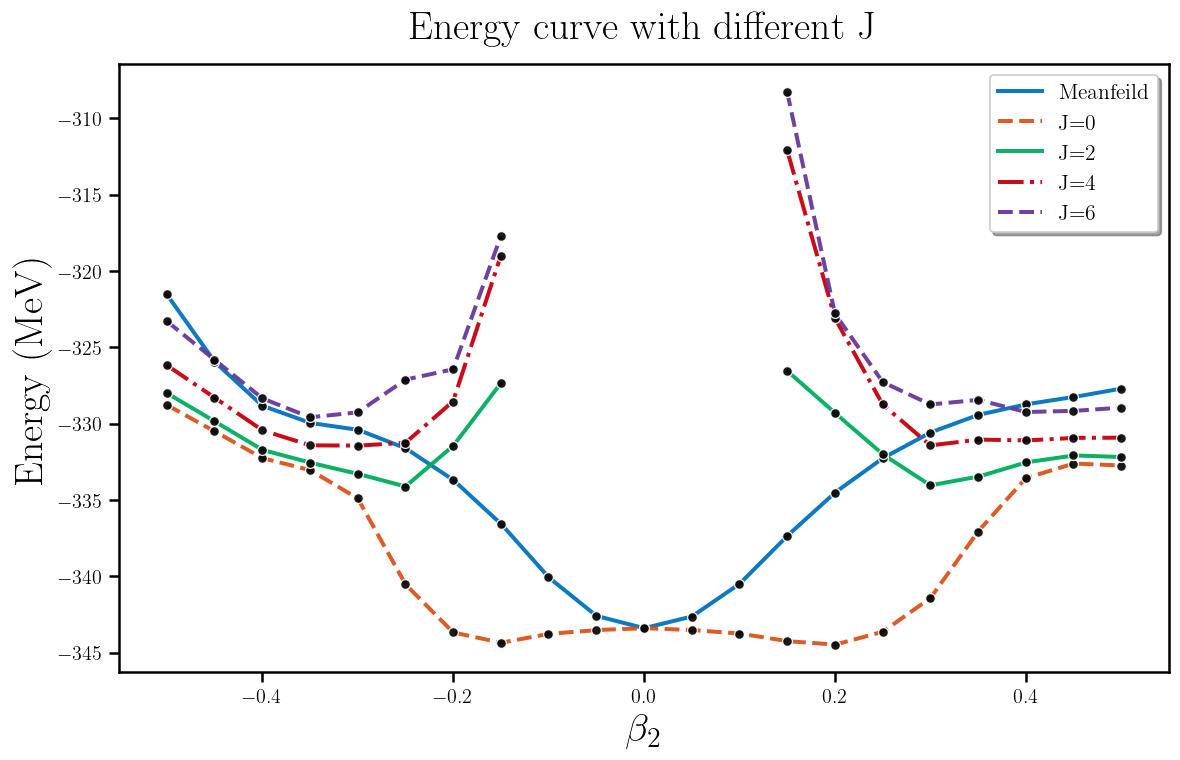

In [ ]:
df_origin = df.copy()
df_copy = final_df.copy()

x = df_copy['beta2'].values.astype(float)
y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']
labels    = ['Meanfeild', 'J=0', 'J=2', 'J=4', 'J=6']
xlabel   = r"$\beta_2$"
ylabel    = "Energy (MeV)"
title     = f"Energy curve with different J "
# save_path_plus = f"{save_path}/{name}_positive_beta2_energy_curve.png"

# 绘图，beta2作为x轴，Etot，energy_J0, energy_J2,energy_J4,energy_J6作为y轴, 绘制于同一附图中。颜色和线条配置采用palettes.group6和palettes.linestyles
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# 假设你的数据框是 merged_nodio_plus
merged = df_copy.copy()   # 建议 copy 避免 SettingWithCopyWarning

# 排序（非常重要！插值要求 x 单调递增）
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]

# 颜色 / 线型
colors = palettes.nature5
linestyles = palettes.linestyles

fontsize = 24
fontweight = 'bold'

plt.figure(figsize=(10, 6.5), dpi=120)
# 遍历每条曲线
for i, y_col in enumerate(y_columns):
        # 获取当前列的数值数据（注意转换为 float 避免类型错误）
        y_data = merged[y_col].astype(float).values
        # print(type(merged))
        # 绘制平滑曲线（如果需要插值）
        plt.plot(x, y_data,
                color=colors[i % len(colors)],
                linestyle=linestyles[i % len(linestyles)],
                linewidth=2.4,
                alpha=0.95,
                label=labels[i])
        # print(type(df_origin))

x = df_origin['beta2'].values.astype(float)
for i, y_col in enumerate(y_columns):
        y_data = df_origin[y_col].astype(float).values
        # print(len(y_data))
        # 叠加原始数据点（黑色小圆点）
        plt.scatter(x, y_data,
                color='black',
                s=35,
                edgecolor='white',
                linewidth=0.8,
                zorder=10,
                alpha=0.9)

plt.ylabel(ylabel, fontsize=fontsize, fontweight=fontweight)
plt.xlabel(xlabel, fontsize=fontsize, fontweight=fontweight)
plt.title(title, fontsize=fontsize, fontweight=fontweight, pad=15)

plt.legend(fontsize=13, loc='best', frameon=True, shadow=True, fancybox=True)


# 黑色强调实验值（如果你有实验点，可在这里额外画）
# plt.scatter(beta2_exp, Etot_exp, color='red', s=80, marker='*', zorder=20, label='Exp.')

plt.tight_layout()

In [ ]:
df = cores[list(cores.keys())[0]].df
# print(df)
df_origin = df[["beta2",'energy_J0']]
# print(df1.head())
# df_origin = 
df_plus = df[df['beta2']>0]
df_plus = df_plus[['energy_J2', 'energy_J4', 'energy_J6']]
df_minus = df[df['beta2']<0]
df_minus = df_minus[['energy_J2', 'energy_J4', 'energy_J6']]
# df_plus = df2[]
# print(df2.head())
# 合并数据
df = pd.concat([df_origin, df_plus, df_minus],axis=1)
print(df.head())



   beta2  energy_J0  energy_J2  energy_J4  energy_J6  energy_J2  energy_J4  \
0  -0.50 -328.77382        NaN        NaN        NaN -327.99518 -326.17121   
1  -0.45 -330.49651        NaN        NaN        NaN -329.84063 -328.29084   
2  -0.40 -332.25800        NaN        NaN        NaN -331.71858 -330.43327   
3  -0.35 -333.03380        NaN        NaN        NaN -332.55586 -331.42427   
4  -0.30 -334.88782        NaN        NaN        NaN -333.28470 -331.44585   

   energy_J6  
0 -323.28857  
1 -325.80473  
2 -328.34164  
3 -329.58755  
4 -329.26993  


In [ ]:
class DataManger:
    def __init__(self, dfdict, label_list, names):
        """
        用来处理相同结构的df的数据，用于对比
        """
        self.dfdict = dfdict 
        self.label_list = label_list
        self.names = names
        self.same_names_dict = {}
        
        self.contrast()
        self.sort_out_the_same_names()
        


    def sort_out_the_same_names(self):
        
        for i in range(len(self.label_list)):
            self.same_names_dict[names[i]] = []
            for key, core in self.dfdict.items():
                # print(names[i])
                

                if self.label_list[i] in key:
                    # print(self.same_names_dict)
                    # print(self.label_list[i])
                    # print(core.df.head(1))
                    # print(key)
                    # print(self.label_list[i] in key)
                    self.same_names_dict[names[i]].append({core.ID:core.df})

    def contrast(self):
        if len(self.label_list) == len(self.names):
            pass
        else:
            raise ValueError("数据集数量和标签数量不一致")
        
dfdict = cores
label_num = list(cores.keys())[1].split("_")
names = ["Aele", "n0f", "pnp", "betas"]
datamanger = DataManger(dfdict, label_num, names)
# print(len(datamanger.same_names_dict[names[1]]))
print(datamanger.same_names_dict[names[1]])
# print(datamanger.same_names_dict[names[1]][1].head())



[{'40Ca_6_111_20':     beta2  beta3        Etot  charge-Radius  energy_J0  energy_J2  energy_J4  \
0   -0.50    0.0 -321.533124       3.692985 -328.77382 -327.99518 -326.17121   
1   -0.45    0.0 -325.938235       3.637738 -330.49651 -329.84063 -328.29084   
2   -0.40    0.0 -328.826140       3.584697 -332.25800 -331.71858 -330.43327   
3   -0.35    0.0 -329.950974       3.545072 -333.03380 -332.55586 -331.42427   
4   -0.30    0.0 -330.395140       3.533501 -334.88782 -333.28470 -331.44585   
5   -0.25    0.0 -331.599439       3.525295 -340.52050 -334.12401 -331.26146   
6   -0.20    0.0 -333.674085       3.516074 -343.67854 -331.47017 -328.55171   
7   -0.15    0.0 -336.546546       3.505728 -344.35792 -327.35989 -319.00497   
8   -0.10    0.0 -340.061618       3.492011 -343.77552        NaN        NaN   
9   -0.05    0.0 -342.592148       3.477820 -343.52514        NaN        NaN   
10   0.00    0.0 -343.405622       3.473241 -343.39822        NaN        NaN   
11   0.05    0.0 -342